## **Praktikum Pengolahan Sinyal Digital**



---


* Nama: Raka Muhammad Al Hafidz
* NIM: 241344087
* Kelas: 2C-TNK


# Modul 10 - Transformasi Fourier

Melihat spektrum dari komponen suatu sinyal

## Bagian Pendahuluan




Buat suatu sinyal dasar yang merupakan gabungan sinyal sinusoidal yang masing-masing memiliki frekuensi 1 Hz, 20 Hz, 1/2 amplitudo 100 Hz dan 1/4 amplitudo 300 Hz, set frekuensi sampling 1000 Hz dan durasi selama 2 detik. Plot kan hasil sinyal nya

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
dur = 2

A = [1, 1, 0.5, 0.25]
freqs = [1, 20, 100, 300]
fs = 1000

t = np.linspace(0, dur, int(dur*fs), endpoint=False)
s = sum(A[i]*np.sin(2 * np.pi * f * t) for i, f in enumerate(freqs))

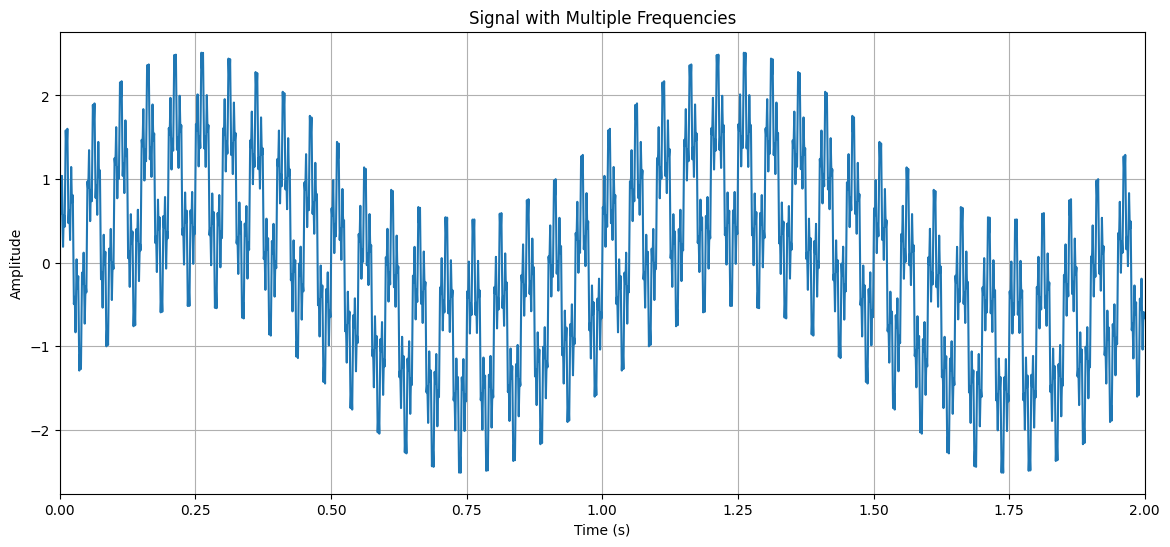

In [83]:
plt.figure(figsize=(14, 6))
plt.plot(t, s)
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.title('Signal with Multiple Frequencies')
plt.xlim(0, dur)
plt.grid()
plt.show()

## Bagian Percobaan

1. Gunakan fungsi ```np.fft.rfft()``` terhadap sinyal yang dibuat Plot hasil fft tersebut. Jangan lupa menggunakan ```np.fft.fftfreq()``` sebagai sumbu x.


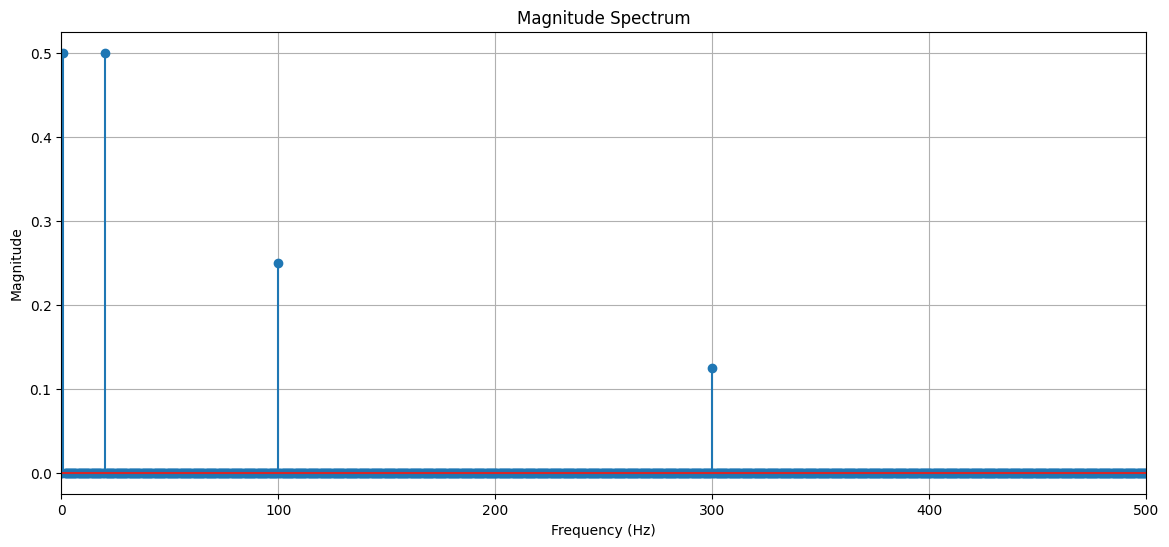

In [11]:
n_total = len(s)

rfft = np.fft.rfft(s)
rfft_magnitude = np.abs(rfft)/n_total
x = np.fft.rfftfreq(n_total, 1/fs)

plt.figure(figsize=(14, 6))
plt.stem(x, rfft_magnitude)
plt.xlabel('Frequency (Hz)')
plt.ylabel('Magnitude')
plt.title('Magnitude Spectrum')
plt.xlim(0, fs/dur)
plt.grid()
plt.show()


2. Pada array hasil fft hilangkan amplitudo untuk frekuensi diatas 10 Hz (proses ini disebut thresholding). Lalu gunakan ```np.fft.irfft()``` terhadap hasil thresholding tersebut

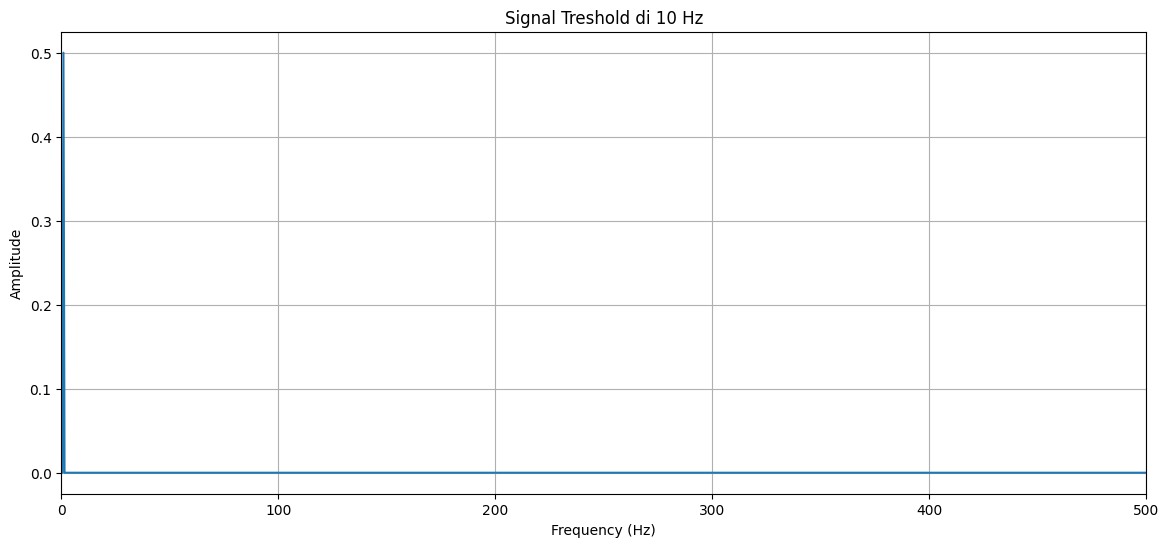

In [86]:
rfft_n_total = len(rfft_magnitude)

rfft_10 = rfft.copy()

for i in range(rfft_n_total):
    if x[i] > 10:
        rfft_10[i] = 0

rfft_10_magnitude = np.abs(rfft_10)/n_total

plt.figure(figsize=(14, 6))
plt.plot(x, rfft_10_magnitude)
plt.xlabel('Frequency (Hz)')
plt.ylabel('Amplitude')
plt.title('Signal Treshold di 10 Hz')
plt.xlim(0, fs/dur)
plt.grid()
plt.show()

Hasil rFFT di-threshold dengan mengosongkan komponen frekuensi di atas 10 Hz, lalu dikembalikan ke domain waktu memakai `np.fft.irfft()`.

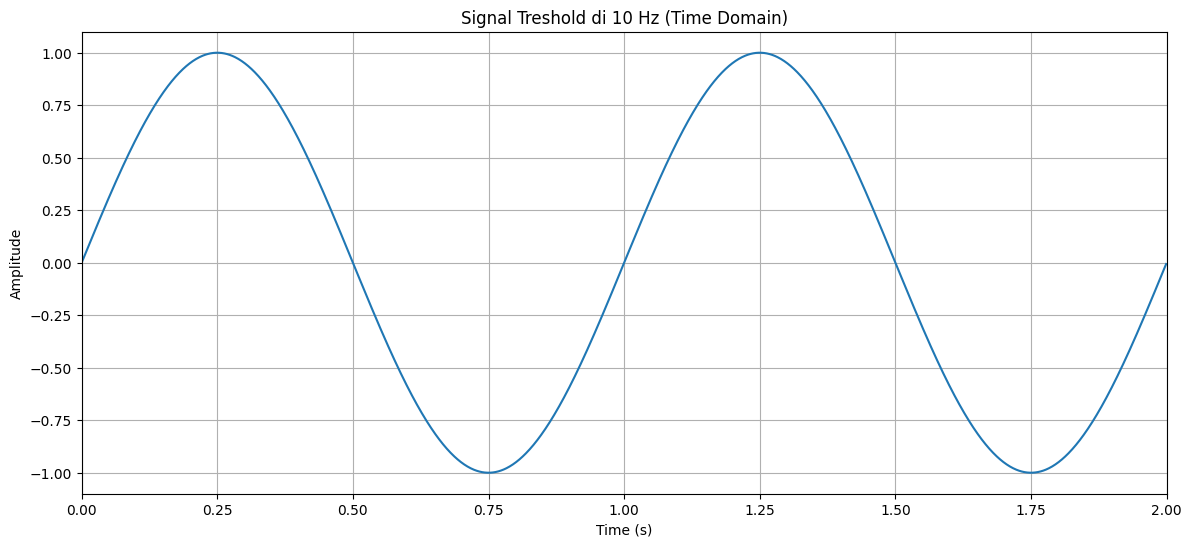

In [87]:
s_10 = np.fft.irfft(rfft_10, n_total)

plt.figure(figsize=(14, 6))
plt.plot(t, s_10)
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.title('Signal Treshold di 10 Hz (Time Domain)')
plt.xlim(0, dur)
plt.grid()
plt.show()

3. Lakukan hal yang sama pada array hasil fft, namun kali ini hilangkan amplitudo untuk frekuensi diluar frekuensi 9 Hz s/d 110 Hz. Lalu gunakan ```np.fft.irfft()``` terhadap hasil thresholding tersebut

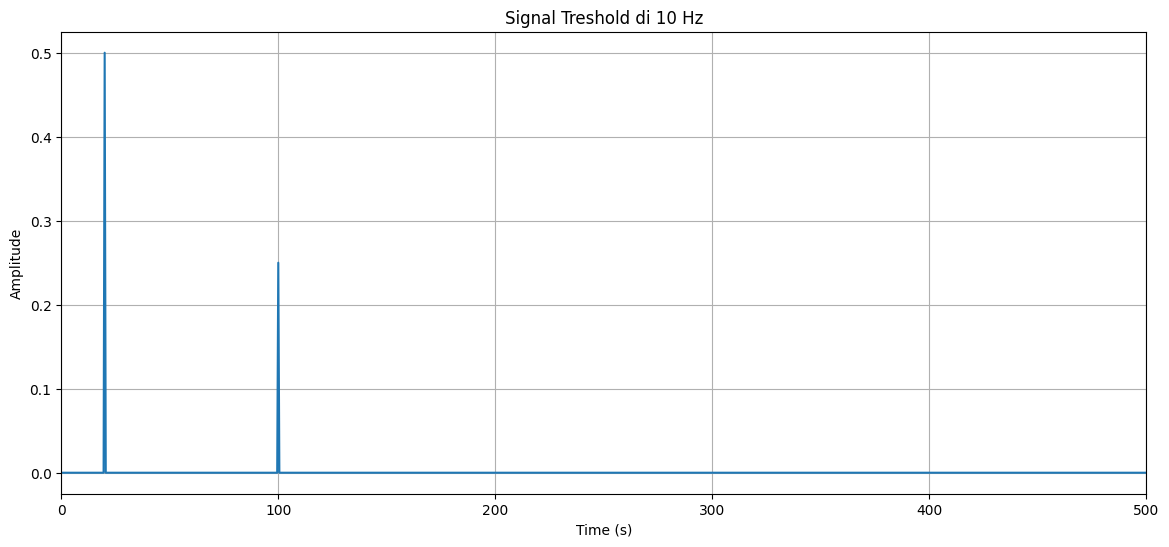

In [88]:
rfft_9_110 = rfft.copy()

for i in range(rfft_n_total):
    if x[i] < 9 or x[i] > 110:
        rfft_9_110[i] = 0

rfft_9_110_magnitude = np.abs(rfft_9_110)/n_total

plt.figure(figsize=(14, 6))
plt.plot(x, rfft_9_110_magnitude)
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.title('Signal Treshold di 10 Hz')
plt.xlim(0, fs/dur)
plt.grid()
plt.show()

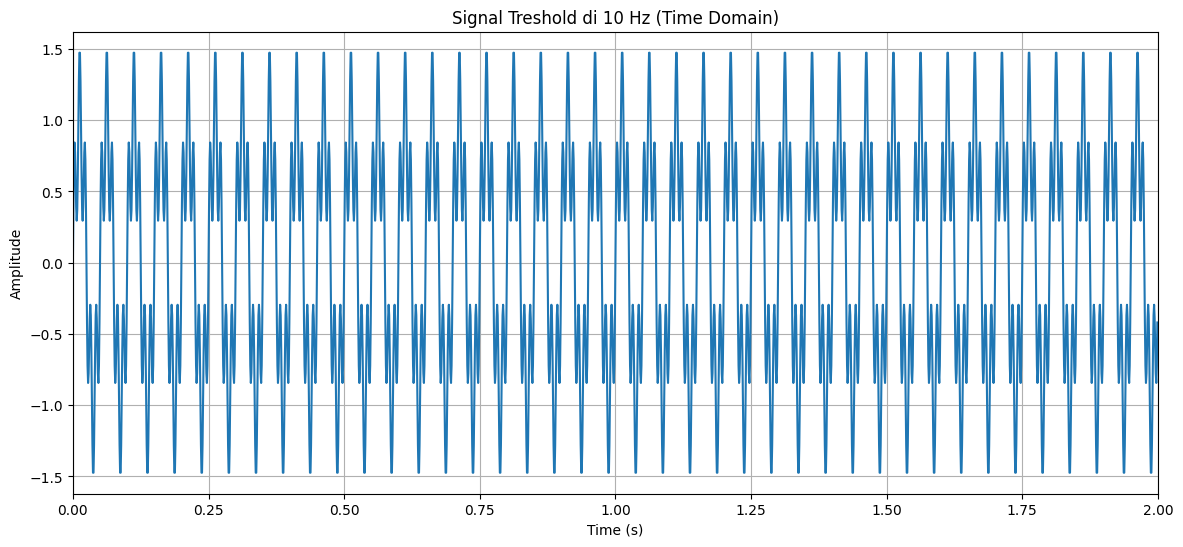

In [89]:
s_9_110 = np.fft.irfft(rfft_9_110, n_total)

plt.figure(figsize=(14, 6))
plt.plot(t, s_9_110)
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.title('Signal Treshold di 10 Hz (Time Domain)')
plt.xlim(0, dur)
plt.grid()
plt.show()

Penjelasan singkat:
- `rfft_10` dan `rfft_9_110` dibuat dari `rfft` lalu komponen di luar batas frekuensi di-nol-kan. Baris `if x[i] > 10: rfft_10[i] = 0` menghapus semua puncak di atas 10 Hz, sehingga pada plot spektrum hanya sisa komponen rendah (mis. 1 Hz). Baris `if x[i] < 9 or x[i] > 110` menyisakan rentang 9–110 Hz, sehingga puncak 20 Hz dan 100 Hz masih terlihat.
- `rfft_10_magnitude` dan `rfft_9_110_magnitude` menghitung magnitudo spektrum untuk ditampilkan pada plot. Akibatnya, garis plot spektrum menjadi “lebih bersih” karena puncak di luar ambang sudah dihilangkan.
- `np.fft.irfft(...)` mengubah spektrum yang sudah di-threshold kembali ke domain waktu. Plot `s_10` menjadi sinyal yang hanya berisi komponen rendah (gelombang lambat), sedangkan `s_9_110` menampilkan sinyal hasil gabungan frekuensi di rentang 9–110 Hz (lebih “cepat” dibanding `s_10`).

4. Plot masing-masing hasil. Pertama plot menunjukkan sinyal asal dan hasil fftnya.
Lalu buat plot kedua untuk plot hasil fft, hasil thresholding, dan sinyal hasil invers fft.

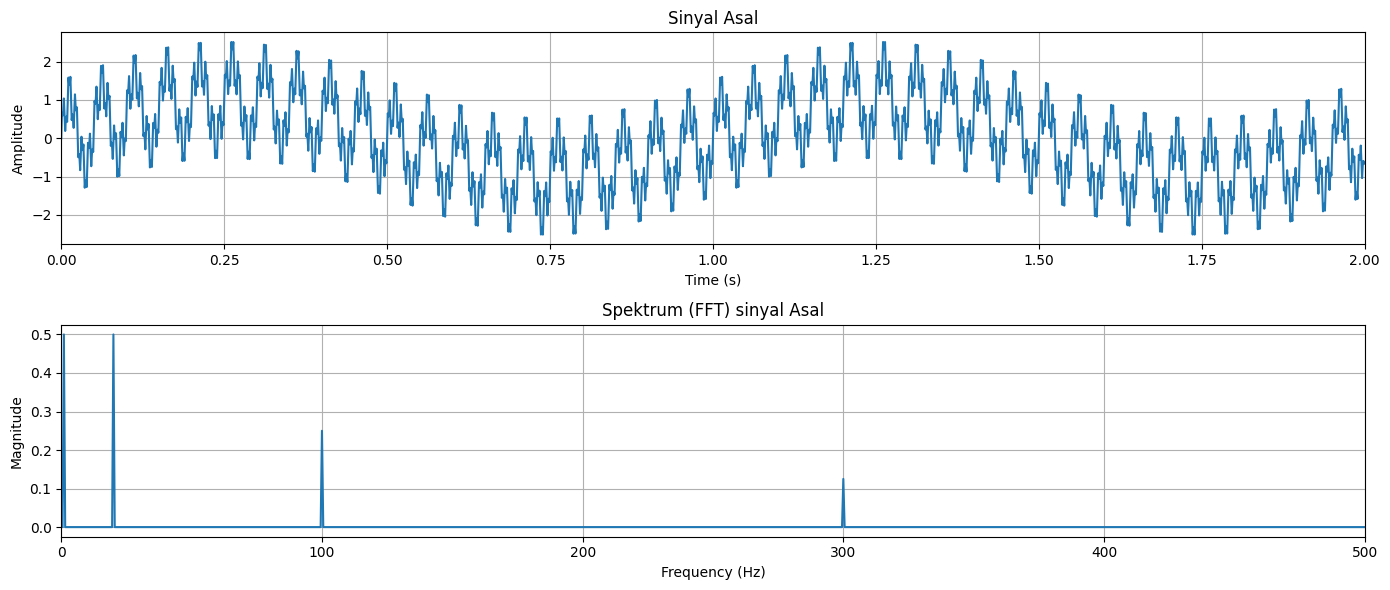

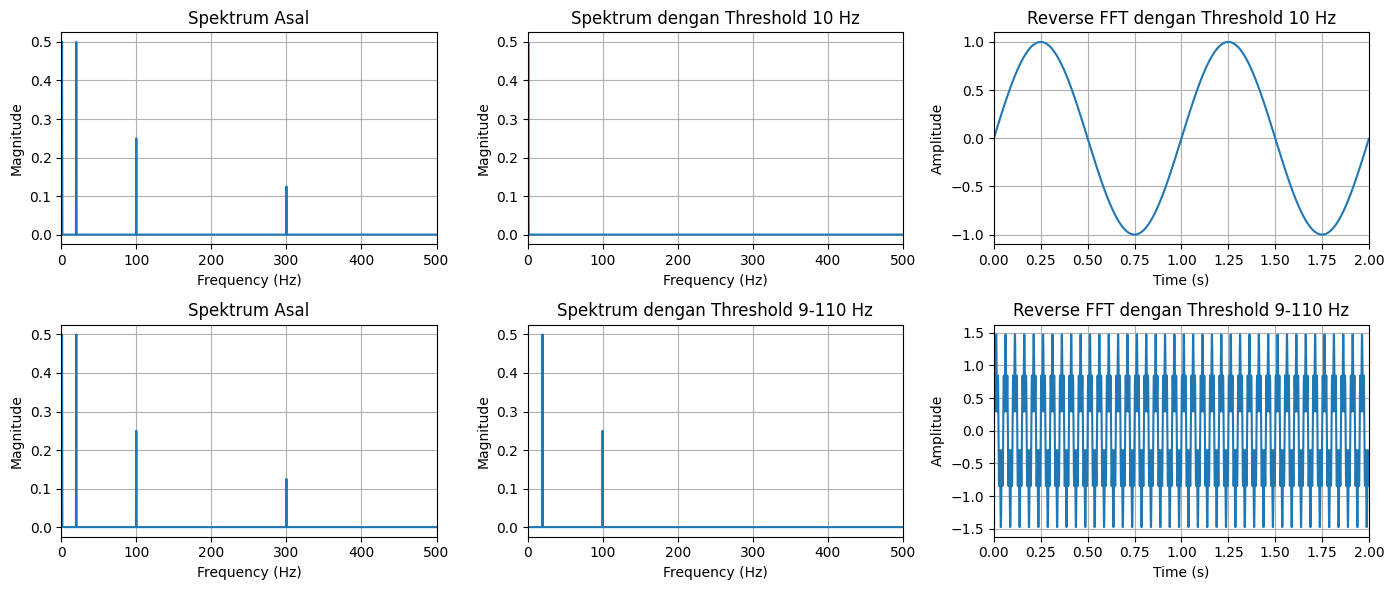

In [90]:
fig, axes = plt.subplots(2, 1, figsize=(14, 6))

axes[0].plot(t, s)
axes[0].set_xlabel('Time (s)')
axes[0].set_ylabel('Amplitude')
axes[0].set_title('Sinyal Asal')
axes[0].set_xlim(0, dur)
axes[0].grid()

axes[1].plot(x, rfft_magnitude)
axes[1].set_xlabel('Frequency (Hz)')
axes[1].set_ylabel('Magnitude')
axes[1].set_title('Spektrum (FFT) sinyal Asal')
axes[1].set_xlim(0, fs/dur)
axes[1].grid()
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(2, 3, figsize=(14, 6))

#=================================== ATAS ===================================
axes[0, 0].plot(x, rfft_magnitude)
axes[0, 0].set_xlabel('Frequency (Hz)')
axes[0, 0].set_ylabel('Magnitude')
axes[0, 0].set_title('Spektrum Asal')
axes[0, 0].set_xlim(0, fs/dur)
axes[0, 0].grid()

axes[0, 1].plot(x, rfft_10_magnitude)
axes[0, 1].set_xlabel('Frequency (Hz)')
axes[0, 1].set_ylabel('Magnitude')
axes[0, 1].set_title('Spektrum dengan Threshold 10 Hz')
axes[0, 1].set_xlim(0, fs/dur)
axes[0, 1].grid()

axes[0, 2].plot(t, s_10)
axes[0, 2].set_xlabel('Time (s)')
axes[0, 2].set_ylabel('Amplitude')
axes[0, 2].set_title('Reverse FFT dengan Threshold 10 Hz')
axes[0, 2].set_xlim(0, dur)
axes[0, 2].grid()


#=================================== BAWAH ===================================

axes[1, 0].plot(x, rfft_magnitude)
axes[1, 0].set_xlabel('Frequency (Hz)')
axes[1, 0].set_ylabel('Magnitude')
axes[1, 0].set_title('Spektrum Asal')
axes[1, 0].set_xlim(0, fs/dur)
axes[1, 0].grid()

axes[1, 1].plot(x, rfft_9_110_magnitude)
axes[1, 1].set_xlabel('Frequency (Hz)')
axes[1, 1].set_ylabel('Magnitude')
axes[1, 1].set_title('Spektrum dengan Threshold 9-110 Hz')
axes[1, 1].set_xlim(0, fs/dur)
axes[1, 1].grid()

axes[1, 2].plot(t, s_9_110)
axes[1, 2].set_xlabel('Time (s)')
axes[1, 2].set_ylabel('Amplitude')
axes[1, 2].set_title('Reverse FFT dengan Threshold 9-110 Hz')
axes[1, 2].set_xlim(0, dur)
axes[1, 2].grid()

plt.tight_layout()
plt.show()



Penjelasan:
- `rfft = np.fft.rfft(s)` mengubah sinyal waktu `s` menjadi representasi frekuensi (domain frekuensi). Hasilnya berupa koefisien kompleks yang menyimpan informasi amplitudo dan fase untuk tiap frekuensi. Karena input real, `rfft` hanya menyimpan setengah spektrum (frekuensi non-negatif) agar efisien.
- `rfft_magnitude = np.abs(rfft)/n_total` mengubah koefisien kompleks menjadi magnitudo. Ini dipakai untuk membaca komponen frekuensi apa saja yang dominan di sinyal, yaitu puncak pada frekuensi yang ada di sinyal asal.
- Proses threshold dilakukan dengan menyalin spektrum lalu men-set koefisien di luar batas menjadi nol (misalnya `rfft_10` dan `rfft_9_110`). Ini adalah filter frekuensi sederhana: membuang komponen yang tidak diinginkan agar hanya frekuensi tertentu yang tersisa.

- `np.fft.irfft(...)` melakukan transformasi balik dari domain frekuensi ke domain waktu. Karena koefisien tertentu sudah di-nol-kan, sinyal waktu hasil `irfft` hanya tersusun dari komponen frekuensi yang lolos threshold. Itulah sebabnya `s_10` hanya memuat komponen rendah (<= 10 Hz), sedangkan `s_9_110` hanya memuat komponen di rentang 9-110 Hz.
- Sinyal hasil threshold 9–110 terlihat mirip sinyal awal karena dua komponen dominan (20 Hz dan 100 Hz) tetap lolos, sehingga bentuk gelombang gabungannya masih mendekati sinyal asli. Secara konsep, threshold 10 Hz adalah LPF (low-pass filter), sedangkan threshold 9–110 Hz berperan sebagai BPF (band-pass filter) yang hanya melewatkan pita frekuensi tertentu.


- Alur: sinyal waktu -> rFFT (ubah ke domain frekuensi) -> threshold (pilih komponen frekuensi yang diinginkan) -> iRFFT (kembali ke domain waktu) -> sinyal hasil dengan komponen frekuensi yang sudah difilter.

5. Untuk sample .wav yang diberikan lakukan transformasi Fourier lalu, lakukan thresholding untuk frekuensi diatas 9000 Hz, 3000 Hz, dan 500 Hz

- Load Sinyal
- Lakukan FFT
- Filter untuk nilai ambang frekuensi 9000, 3000, 500Hz.
- Invers FFT
- List hasil

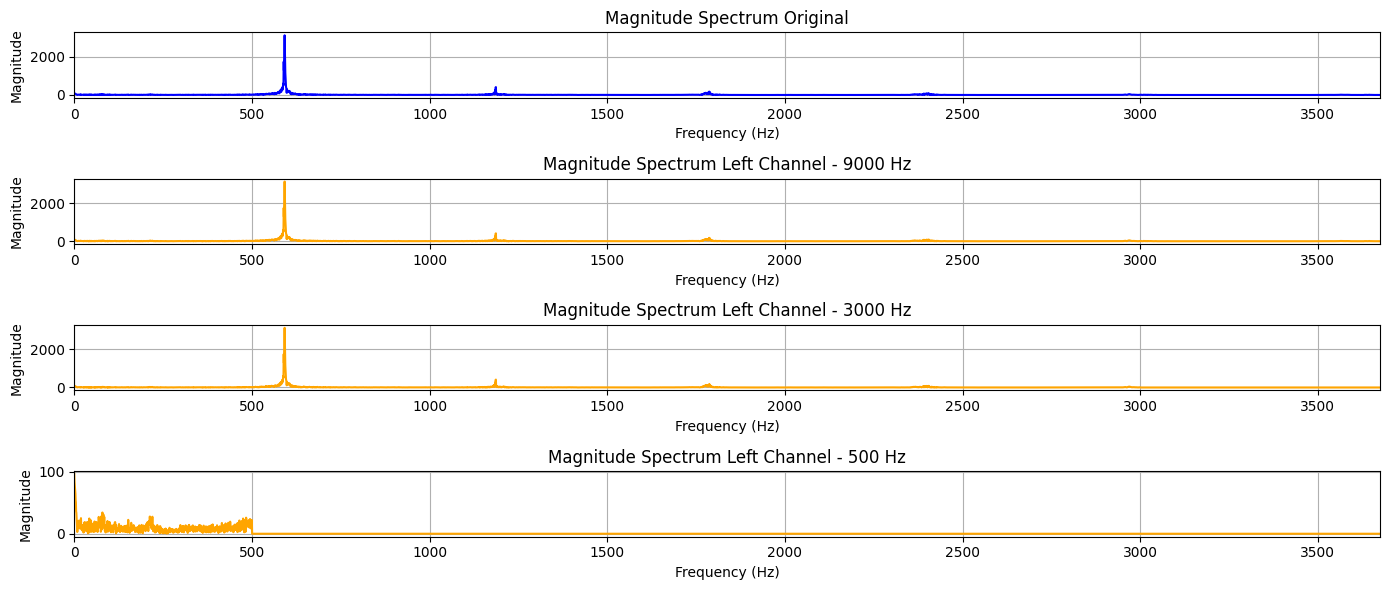

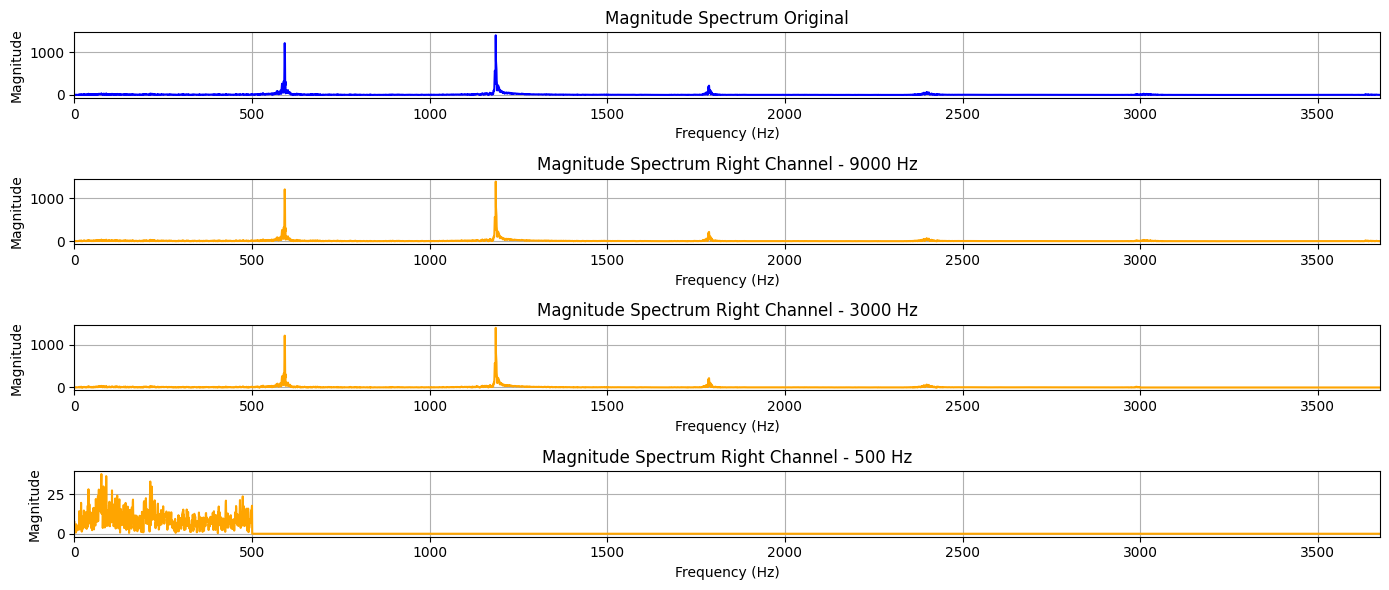

Audio dengan Threshold 9000 Hz (Kiri):


Audio dengan Threshold 9000 Hz (Kanan):


Audio dengan Threshold 3000 Hz (Kiri):


Audio dengan Threshold 3000 Hz (Kanan):


Audio dengan Threshold 500 Hz (Kiri):


Audio dengan Threshold 500 Hz (Kanan):


Audio Asli:


In [ ]:
from IPython.display import Audio
from IPython.display import display
from scipy.io import wavfile

LEFT = 0
RIGHT = 1

wav_audio = 'piano_d_D_major.wav'
fs_micwav, mic_signal_wav = wavfile.read(wav_audio)

audio =  mic_signal_wav.astype(np.float32)
right_ch = audio[:,1]
left_ch = audio[:,0]

dur_wav = len(mic_signal_wav) / fs_micwav
t_wav = np.linspace(0, dur_wav, int(fs_micwav * dur_wav), endpoint=False)

left_fft = np.fft.rfft(left_ch)
right_fft = np.fft.rfft(right_ch)

wav_n_total = len(audio)
right_n_total = len(right_ch)
left_n_total = len(left_ch)

x_wav = np.fft.rfftfreq(wav_n_total, 1/fs_micwav)
x_l_wav = np.fft.rfftfreq(left_n_total, 1/fs_micwav)
x_r_wav = np.fft.rfftfreq(right_n_total, 1/fs_micwav)

rows, cols = (3, 2)
irfft_tresholded = [[0]*cols for _ in range(rows)]
rfft_tresholded  = [[0]*cols for _ in range(rows)]

freqs = [9000, 3000, 500]

l_rfft_magnitude = np.abs(left_fft)/left_n_total

for i in range(len(freqs)):

   wavfft_threshold_left = left_fft.copy()
   wavfft_threshold_right = right_fft.copy()

   for j in range(len(l_rfft_magnitude)):
      if x_l_wav[j] > freqs[i]:
         wavfft_threshold_left[j] = 0
      if x_r_wav[j] > freqs[i]:
         wavfft_threshold_right[j] = 0

   irfft_tresholded[i][LEFT] = np.fft.irfft(wavfft_threshold_left, len(mic_signal_wav))
   irfft_tresholded[i][RIGHT] = np.fft.irfft(wavfft_threshold_right, len(mic_signal_wav))

   rfft_tresholded[i][LEFT] = wavfft_threshold_left
   rfft_tresholded[i][RIGHT] = wavfft_threshold_right

fig, axes = plt.subplots(4, 1, figsize=(14, 6))
for i in range(4):
   if i == 0:
      axes[i].plot(x_l_wav, np.abs(left_fft)/left_n_total, color = 'blue')
   else:
      axes[i].plot(x_l_wav, np.abs(rfft_tresholded[i-1][LEFT])/left_n_total, color='orange')
   axes[i].set_xlabel('Frequency (Hz)')
   axes[i].set_ylabel('Magnitude')
   axes[i].set_title(f'Magnitude Spectrum Left Channel - {freqs[i-1]} Hz' if i > 0 else 'Magnitude Spectrum Original')
   axes[i].set_xlim(0, fs_micwav/12)
   axes[i].grid()
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(4, 1, figsize=(14, 6))
for i in range(4):
   if i == 0:
      axes[i].plot(x_r_wav, np.abs(right_fft)/right_n_total, color = 'blue')
   else:
      axes[i].plot(x_r_wav, np.abs(rfft_tresholded[i-1][RIGHT])/right_n_total, color='orange')
   axes[i].set_xlabel('Frequency (Hz)')
   axes[i].set_ylabel('Magnitude')
   axes[i].set_title(f'Magnitude Spectrum Right Channel - {freqs[i-1]} Hz' if i > 0 else 'Magnitude Spectrum Original')
   axes[i].set_xlim(0, fs_micwav/12)
   axes[i].grid()
plt.tight_layout()
plt.show()

for i in range(len(freqs)):
   print(f"Audio dengan Threshold {freqs[i]} Hz (Kiri):")
   display(Audio(irfft_tresholded[i][LEFT], rate=fs_micwav))
   print(f"Audio dengan Threshold {freqs[i]} Hz (Kanan):")
   display(Audio(irfft_tresholded[i][RIGHT], rate=fs_micwav))

print("Audio Asli:")
display(Audio(left_ch, rate = fs_micwav))

#Ya Allah panjang banget untuk 1 soal 😭😭😭


Penjelasan:
- Proses dimulai dengan membaca file WAV, lalu memisahkan channel audio kiri dan kanan. Setiap channel diubah ke domain frekuensi memakai `np.fft.rfft`, sehingga spektrum hanya menyimpan komponen frekuensi non-negatif (tanpa imajiner minus).
- Thresholding dilakukan dengan menyalin spektrum lalu men-set koefisien di atas batas (9000, 3000, 500 Hz) menjadi nol. Ini adalah filter low-pass sederhana yang membuang komponen frekuensi tinggi.
- Setelah itu `np.fft.irfft` mengembalikan spektrum yang sudah difilter ke domain waktu. Hasilnya adalah sinyal audio baru yang hanya berisi komponen frekuensi di bawah batas tersebut.

- Saat cutoff 500 Hz, hampir semua komponen frekuensi di atas 500 Hz dibuang, sehingga energi sinyal berkurang drastis. Puncak magnitudo maksimum jadi lebih kecil (bisa dilihat pada gambar, max. hanya 25 tau 100) dibanding cutoff 3000/9000 Hz (>2000) karena hanya sedikit komponen yang tersisa.
- Cutoff 3000/9000 Hz masih mempertahankan lebih banyak harmonik, sehingga magnitudo puncak bisa lebih tinggi karena lebih banyak energi spektral yang masih ada.

Perbedaan suara antar threshold:
- 9000 Hz: suara masih relatif jernih dan terang karena sebagian besar harmonik tinggi tetap ada.
- 3000 Hz: suara terdengar lebih tertutup/muffled, detail dan kecerahan berkurang, tapi bentuk nada utama masih jelas.
- 500 Hz: suara sangat "gelap" dan mendem, banyak detail hilang, tersisa komponen rendah saja sehingga terasa seperti suara dari balik dinding atau filter berat. Jujur... suaranya seperti ledakan di dalam air



---


© Prof. Hertog Nugroho, Teguh Ginanjar S.T., M.T, Muhammad Yusuf Fadhlan, SST., M.Sc & Nila Novitasari SST., MSc.

Politeknik Negeri Bandung (2025)